# 🗺️ Testador de Rotas - Totem Backend

Notebook interativo para testar e visualizar as rotas calculadas pelo algoritmo de Dijkstra no backend do Totem Interativo.

## 📋 Funcionalidades

- Testa o endpoint `/routes/{fromBuildingId}?toBuildingId={toBuildingId}`
- Visualiza graficamente o mapa completo com o caminho destacado
- Destaca prédios de origem/destino e seus pontos de entrada
- Executa casos de teste pré-definidos

## 1. Imports e Configuração

Primeiro, vamos importar as bibliotecas necessárias e configurar o ambiente.

In [244]:
!pip install -r requirements.txt

In [245]:
import requests
import matplotlib.pyplot as plt
import networkx as nx
from typing import List, Dict, Tuple

# Configuração do tamanho dos gráficos
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['figure.dpi'] = 100

# URL base da API
BASE_URL = "http://localhost:8080"

print("✅ Bibliotecas importadas com sucesso!")
print(f"📡 API URL: {BASE_URL}")

✅ Bibliotecas importadas com sucesso!
📡 API URL: http://localhost:8080


## 2. Dados do Mapa

Definição dos nós (coordenadas), prédios e arestas do mapa do campus.

In [246]:
import re
import os

# Caminho para o arquivo import.sql
IMPORT_SQL_PATH = os.path.join('..', 'src', 'main', 'resources', 'import.sql')

def parse_import_sql():
    """
    Lê e parseia o arquivo import.sql para extrair nós, prédios e arestas.
    """
    with open(IMPORT_SQL_PATH, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Parsear Nós (Nodes)
    nodes = {}
    node_pattern = r"INSERT INTO node \(x, y\) VALUES \(([-\d.]+),\s*([-\d.]+)\);"
    for match in re.finditer(node_pattern, content):
        x, y = float(match.group(1)), float(match.group(2))
        node_id = len(nodes) + 1
        nodes[node_id] = (x, y)
    
    # Parsear Arestas (Edges)
    edges = []
    edge_pattern = r"INSERT INTO edge \(width, node_a_id, node_b_id\) VALUES \(\d+,\s*(\d+),\s*(\d+)\);"
    for match in re.finditer(edge_pattern, content):
        node_a_id = int(match.group(1))
        node_b_id = int(match.group(2))
        edges.append((node_a_id, node_b_id))
    
    # Parsear Prédios (Buildings)
    buildings = {}
    building_pattern = r"INSERT INTO building \(name, model_path, node_id, edge_id, edge_node_id\) VALUES \('([^']+)',\s*'[^']+',\s*(\d+),\s*\d+,\s*(\d+)\);"
    for match in re.finditer(building_pattern, content):
        name = match.group(1)
        node_id = int(match.group(2))
        edge_node_id = int(match.group(3))
        building_id = len(buildings) + 1
        buildings[building_id] = {
            'name': name,
            'node': node_id,
            'edge_node': edge_node_id
        }
    
    return nodes, edges, buildings

# Carregar dados do import.sql
print("📂 Lendo dados de import.sql...")
NODES, EDGES, BUILDINGS = parse_import_sql()

print(f"✅ {len(NODES)} nós carregados")
print(f"✅ {len(BUILDINGS)} prédios carregados")
print(f"✅ {len(EDGES)} arestas carregadas")
print(f"📍 Fonte: {IMPORT_SQL_PATH}")

📂 Lendo dados de import.sql...
✅ 58 nós carregados
✅ 14 prédios carregados
✅ 38 arestas carregadas
📍 Fonte: ..\src\main\resources\import.sql


## 3. Função para Chamar a API

Função que consome o endpoint de rotas do backend.

In [247]:
def get_route(from_building_id: int, to_building_id: int) -> List[int]:
    """
    Chama o endpoint de rotas e retorna o caminho calculado.
    
    Args:
        from_building_id: ID do prédio de origem
        to_building_id: ID do prédio de destino
    
    Returns:
        Lista com os IDs dos nós no caminho
    """
    try:
        url = f"{BASE_URL}/routes/{from_building_id}?toBuildingId={to_building_id}"
        response = requests.get(url)
        
        if response.status_code == 200:
            return response.json()
        else:
            print(f"❌ Erro {response.status_code}: {response.text}")
            return []
    except Exception as e:
        print(f"❌ Erro ao chamar API: {e}")
        return []

print("✅ Função get_route() definida")

✅ Função get_route() definida


## 4. Função de Visualização

Função que plota o mapa com o caminho calculado destacado.

In [248]:
def plot_route(from_building_id: int, to_building_id: int, path: List[int]):
    """
    Plota o grafo completo com o caminho destacado.
    
    Args:
        from_building_id: ID do prédio de origem
        to_building_id: ID do prédio de destino
        path: Lista com os IDs dos nós no caminho
    """
    # Criar grafo
    G = nx.Graph()
    
    # Adicionar nós com posições
    for node_id, (x, y) in NODES.items():
        G.add_node(node_id, pos=(x, y))
    
    # Adicionar arestas
    for edge in EDGES:
        G.add_edge(edge[0], edge[1])
    
    # Obter posições
    pos = nx.get_node_attributes(G, 'pos')
    
    # Criar figura
    plt.figure(figsize=(16, 12))
    
    # Desenhar todas as arestas em cinza claro
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1, alpha=0.5)
    
    # Desenhar todos os nós em cinza claro
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=100, alpha=0.5)
    
    # Destacar o caminho
    if len(path) > 1:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, 
                              edge_color='blue', width=3, alpha=0.8)
        nx.draw_networkx_nodes(G, pos, nodelist=path, 
                              node_color='blue', node_size=200)
    
    # Obter informações dos prédios
    from_node = BUILDINGS[from_building_id]['node']
    to_node = BUILDINGS[to_building_id]['node']
    from_edge_node = BUILDINGS[from_building_id]['edge_node']
    to_edge_node = BUILDINGS[to_building_id]['edge_node']
    
    # Desenhar nós dos prédios
    nx.draw_networkx_nodes(G, pos, nodelist=[from_node], 
                          node_color='green', node_size=400, label='Origem (Prédio)')
    nx.draw_networkx_nodes(G, pos, nodelist=[to_node], 
                          node_color='red', node_size=400, label='Destino (Prédio)')
    
    # Desenhar edge_nodes (pontos de entrada)
    nx.draw_networkx_nodes(G, pos, nodelist=[from_edge_node], 
                          node_color='lightgreen', node_size=300, 
                          node_shape='s', label='Entrada Origem')
    nx.draw_networkx_nodes(G, pos, nodelist=[to_edge_node], 
                          node_color='lightcoral', node_size=300, 
                          node_shape='s', label='Entrada Destino')
    
    # Linhas conectando prédios aos edge_nodes
    if from_node in pos and from_edge_node in pos:
        plt.plot([pos[from_node][0], pos[from_edge_node][0]], 
                [pos[from_node][1], pos[from_edge_node][1]], 
                'g--', linewidth=2, alpha=0.6)
    
    if to_node in pos and to_edge_node in pos:
        plt.plot([pos[to_node][0], pos[to_edge_node][0]], 
                [pos[to_node][1], pos[to_edge_node][1]], 
                'r--', linewidth=2, alpha=0.6)
    
    # Labels apenas para nós importantes
    important_nodes = set([from_node, to_node, from_edge_node, to_edge_node] + path)
    labels = {node: str(node) for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
    
    # Título
    from_name = BUILDINGS[from_building_id]['name']
    to_name = BUILDINGS[to_building_id]['name']
    plt.title(f'Rota: {from_name} → {to_name}\\nCaminho: {" → ".join(map(str, path))}', 
              fontsize=14, fontweight='bold')
    
    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Salvar automaticamente em test_routes/output
    output_dir = 'output'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    filename = f"rota_{from_building_id}_to_{to_building_id}_{from_name.replace('/', '_')}_to_{to_name.replace('/', '_')}.png"
    output_path = os.path.join(output_dir, filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"💾 Gráfico salvo em: {output_path}")
    
    plt.show()

print("✅ Função plot_route() definida")

✅ Função plot_route() definida


## 5. Lista de Prédios Disponíveis

Veja todos os prédios que você pode usar nos testes.

In [249]:
print("🏢 Prédios Disponíveis:")
print("=" * 50)
for building_id, info in BUILDINGS.items():
    print(f"  {building_id:2d}. {info['name']}")
print("=" * 50)

🏢 Prédios Disponíveis:
   1. tecnopuc
   2. 99 A
   3. 95 A
   4. 97
   5. 95 C
   6. 96 A
   7. 96 B/C/D/F
   8. 96 J
   9. 96 E/H/I/G
  10. 91 B
  11. 94
  12. 93
  13. 92 A
  14. 91 A


## 5.5. Visualização Completa do Grafo

Antes de executar os testes, vamos visualizar a estrutura completa do grafo com todos os nós e arestas.

In [250]:
print("🗺️ ESTRUTURA COMPLETA DO GRAFO")
print("=" * 80)

print("\n📍 TODOS OS NÓS (Coordenadas):")
print("-" * 80)
for node_id in sorted(NODES.keys()):
    x, y = NODES[node_id]
    print(f"  Nó {node_id:2d}: ({x:7.2f}, {y:7.2f})")

print(f"\n✅ Total de nós: {len(NODES)}")

print("\n" + "=" * 80)
print("\n🔗 TODAS AS ARESTAS (Conexões):")
print("-" * 80)
for i, (node1, node2) in enumerate(EDGES, 1):
    x1, y1 = NODES[node1]
    x2, y2 = NODES[node2]
    # Calcular distância euclidiana
    distance = ((x2-x1)**2 + (y2-y1)**2)**0.5
    print(f"  Aresta {i:2d}: Nó {node1:2d} ↔ Nó {node2:2d}  (Distância: {distance:6.2f})")

print(f"\n✅ Total de arestas: {len(EDGES)}")

print("\n" + "=" * 80)
print("\n🏢 PRÉDIOS E SEUS NÓS:")
print("-" * 80)
for building_id in sorted(BUILDINGS.keys()):
    info = BUILDINGS[building_id]
    node = info['node']
    edge_node = info['edge_node']
    x_node, y_node = NODES[node]
    x_edge, y_edge = NODES[edge_node]
    print(f"  {building_id:2d}. {info['name']:15s} → Nó Principal: {node:2d} ({x_node:7.2f}, {y_node:7.2f}) | Entrada: {edge_node:2d} ({x_edge:7.2f}, {y_edge:7.2f})")

print(f"\n✅ Total de prédios: {len(BUILDINGS)}")
print("=" * 80)

🗺️ ESTRUTURA COMPLETA DO GRAFO

📍 TODOS OS NÓS (Coordenadas):
--------------------------------------------------------------------------------
  Nó  1: (   0.00,    0.00)
  Nó  2: ( -13.00,   28.00)
  Nó  3: ( -13.00,  -26.00)
  Nó  4: (  31.45,    8.56)
  Nó  5: (  19.00,   18.29)
  Nó  6: (  30.00,   29.00)
  Nó  7: (   0.00,    0.00)
  Nó  8: (  13.00,   13.00)
  Nó  9: ( -13.00,   13.00)
  Nó 10: ( -13.00,  -22.00)
  Nó 11: (   0.00,    0.00)
  Nó 12: (  13.00,   36.00)
  Nó 13: (  13.00,  -22.00)
  Nó 14: ( -13.00,   -1.50)
  Nó 15: (  13.00,   -1.50)
  Nó 16: (   0.00,    0.00)
  Nó 17: (  13.00,   28.00)
  Nó 18: (   0.00,    0.00)
  Nó 19: (  12.77,  -30.41)
  Nó 20: ( -13.00,   21.00)
  Nó 21: ( -31.00,   21.00)
  Nó 22: ( -31.00,   30.80)
  Nó 23: ( -18.66,   10.50)
  Nó 24: ( -13.00,   10.50)
  Nó 25: (   3.20,    4.58)
  Nó 26: (   3.20,   -1.50)
  Nó 27: (   1.03,   13.00)
  Nó 28: (   1.03,   17.37)
  Nó 29: (   3.10,   28.00)
  Nó 30: (   3.10,   32.76)
  Nó 31: ( -17.62

C:\Users\berna\AppData\Local\Temp\ipykernel_10916\949515990.py:77: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\berna\AppData\Local\Temp\ipykernel_10916\949515990.py:87: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')


💾 Gráfico salvo em: output.png


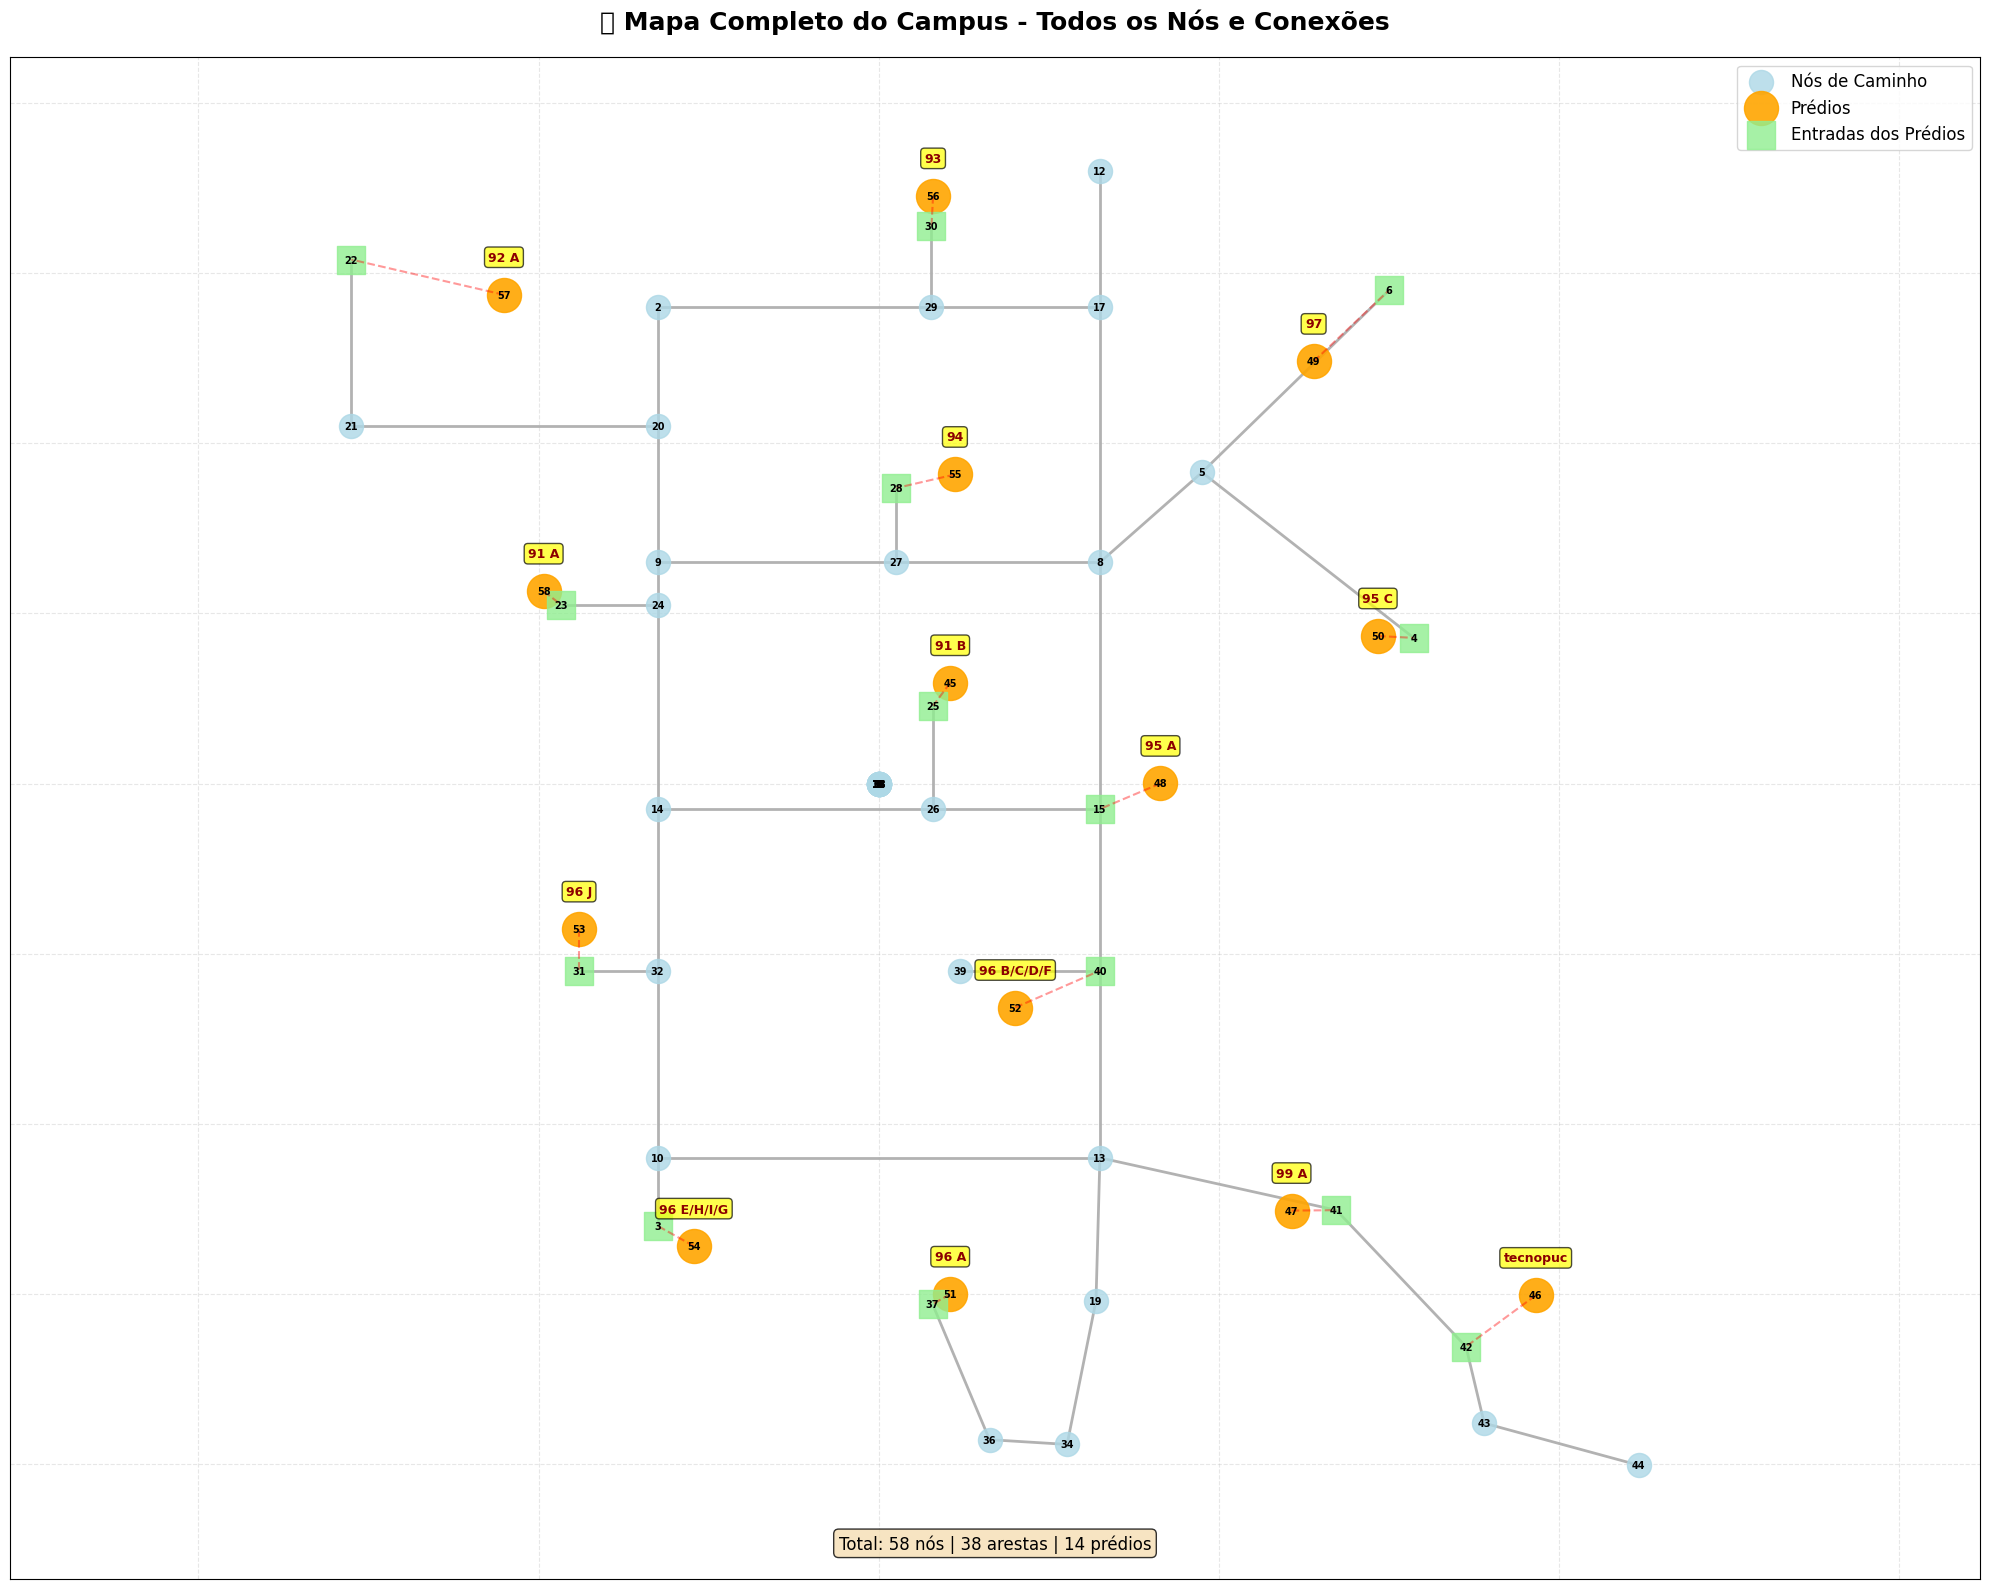

In [251]:
def plot_complete_graph():
    """
    Plota o grafo completo mostrando todos os nós, arestas e prédios.
    """
    # Criar grafo
    G = nx.Graph()
    
    # # Adicionar nós com posições
    for node_id, (x, y) in NODES.items():
        G.add_node(node_id, pos=(x, y))
    
    # Adicionar arestas
    for edge in EDGES:
        G.add_edge(edge[0], edge[1])
    
    # Obter posições
    pos = nx.get_node_attributes(G, 'pos')
    
    # Criar figura maior para melhor visualização
    plt.figure(figsize=(20, 16))
    
    # Desenhar todas as arestas
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=2, alpha=0.6)
    
    # Separar nós por tipo
    building_nodes = [b['node'] for b in BUILDINGS.values()]
    edge_nodes = [b['edge_node'] for b in BUILDINGS.values()]
    regular_nodes = [n for n in NODES.keys() if n not in building_nodes and n not in edge_nodes]
    
    # Desenhar nós regulares (pontos de caminho)
    nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes, 
                          node_color='lightblue', node_size=300, alpha=0.8,
                          label='Nós de Caminho')
    
    # Desenhar nós de prédios
    nx.draw_networkx_nodes(G, pos, nodelist=building_nodes, 
                          node_color='orange', node_size=600, alpha=0.9,
                          label='Prédios')
    
    # Desenhar edge_nodes (pontos de entrada)
    nx.draw_networkx_nodes(G, pos, nodelist=edge_nodes, 
                          node_color='lightgreen', node_size=400, 
                          node_shape='s', alpha=0.8,
                          label='Entradas dos Prédios')
    
    # Adicionar labels para todos os nós
    labels = {node: str(node) for node in NODES.keys()}
    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold')
    
    # Adicionar nomes dos prédios
    building_labels = {}
    for b_id, info in BUILDINGS.items():
        node = info['node']
        building_labels[node] = f"{info['name']}"
    
    # Desenhar labels dos prédios com offset
    for node, label in building_labels.items():
        x, y = pos[node]
        plt.text(x, y + 2, label, fontsize=9, ha='center', 
                fontweight='bold', color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Desenhar linhas conectando prédios aos seus edge_nodes
    for info in BUILDINGS.values():
        node = info['node']
        edge_node = info['edge_node']
        if node in pos and edge_node in pos:
            plt.plot([pos[node][0], pos[edge_node][0]], 
                    [pos[node][1], pos[edge_node][1]], 
                    'r--', linewidth=1.5, alpha=0.4)
    
    plt.title('🗺️ Mapa Completo do Campus - Todos os Nós e Conexões', 
              fontsize=18, fontweight='bold', pad=20)
    plt.legend(loc='upper right', fontsize=12)
    plt.axis('equal')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Adicionar informações estatísticas
    info_text = f"Total: {len(NODES)} nós | {len(EDGES)} arestas | {len(BUILDINGS)} prédios"
    plt.text(0.5, 0.02, info_text, transform=plt.gca().transAxes,
            fontsize=12, ha='center', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Salvar automaticamente em test_routes/outpu
    output_path = 'output.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"💾 Gráfico salvo em: {output_path}")
    
    plt.show()

# Plotar o grafo completo
plot_complete_graph()

## 6. Casos de Teste

Vamos executar alguns casos de teste interessantes!

### Teste 1: Tecnopuc → 99 A (prédios próximos)

🚀 Testando rota: tecnopuc → 99 A
✅ Caminho encontrado com 2 nós
📍 Sequência: 42 → 41
💾 Gráfico salvo em: output\rota_1_to_2_tecnopuc_to_99 A.png


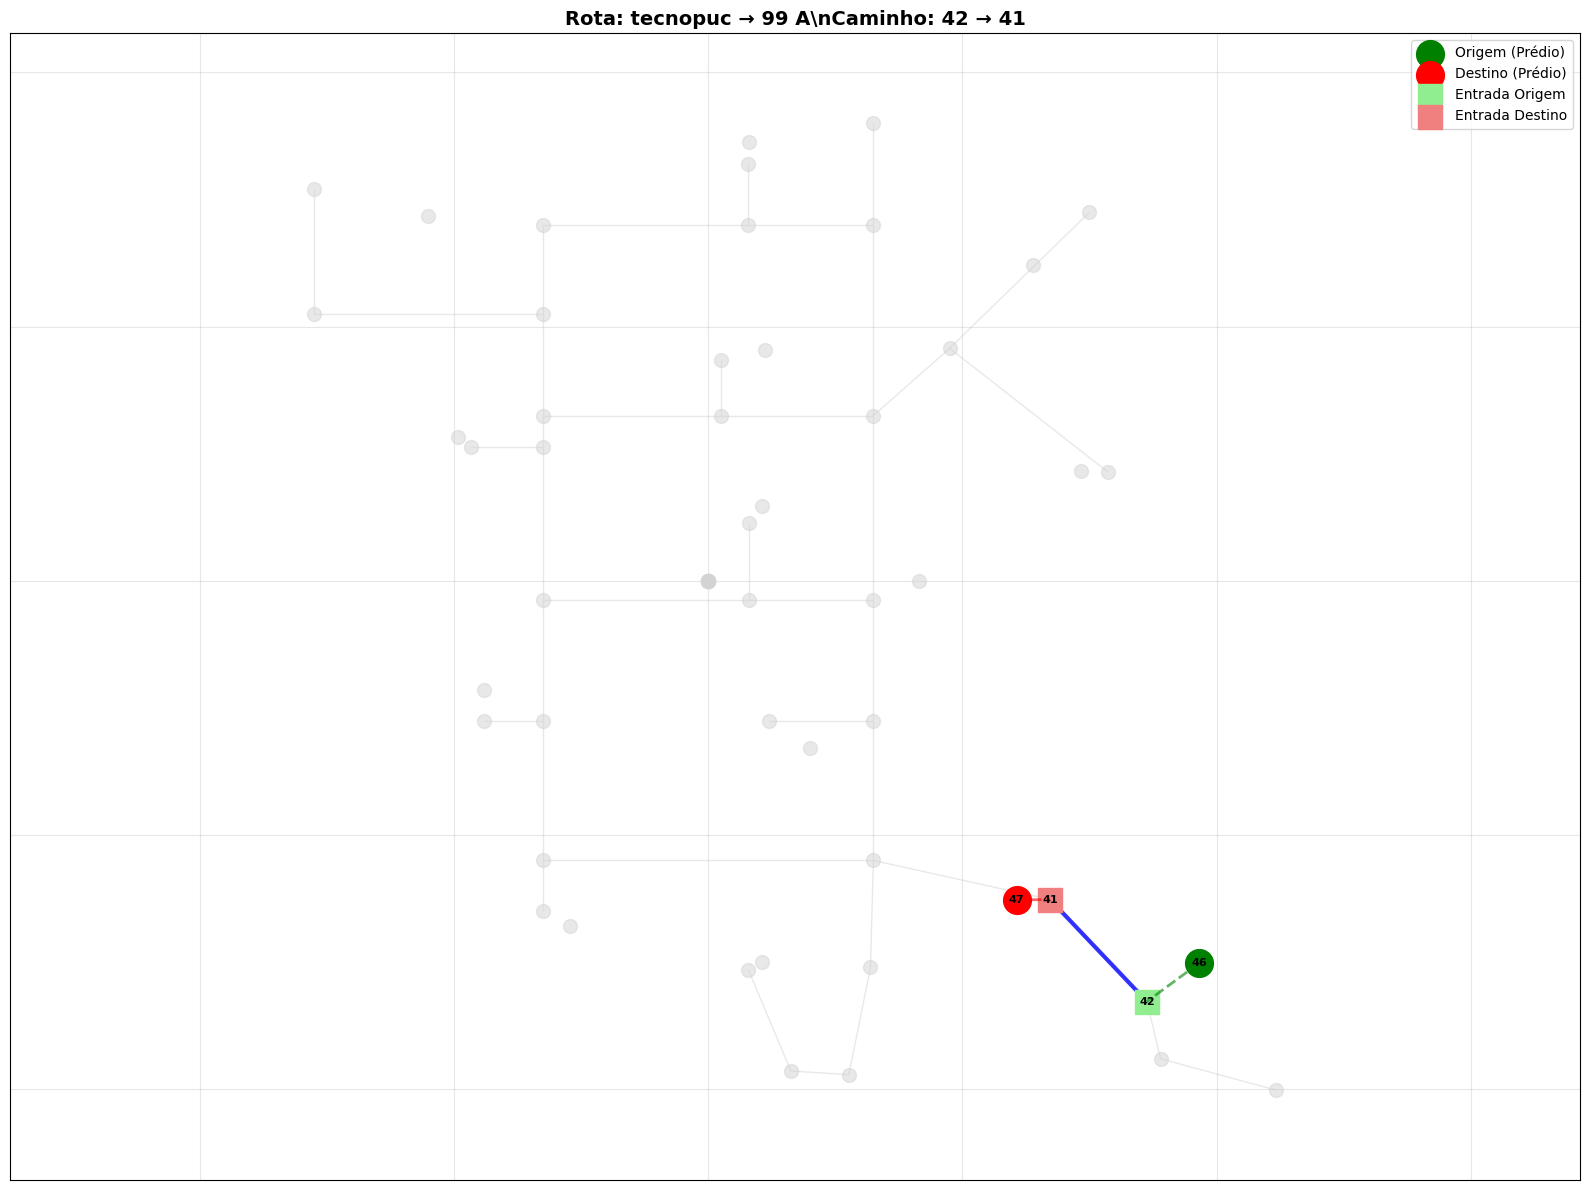

In [252]:
from_id, to_id = 1, 2
print(f"🚀 Testando rota: {BUILDINGS[from_id]['name']} → {BUILDINGS[to_id]['name']}")
path = get_route(from_id, to_id)

if path:
    print(f"✅ Caminho encontrado com {len(path)} nós")
    print(f"📍 Sequência: {' → '.join(map(str, path))}")
    plot_route(from_id, to_id, path)
else:
    print("❌ Nenhum caminho encontrado")

### Teste 2: Tecnopuc → 93 (longa distância)

🚀 Testando rota: tecnopuc → 93
✅ Caminho encontrado com 9 nós
📍 Sequência: 42 → 41 → 13 → 40 → 15 → 8 → 17 → 29 → 30
💾 Gráfico salvo em: output\rota_1_to_12_tecnopuc_to_93.png


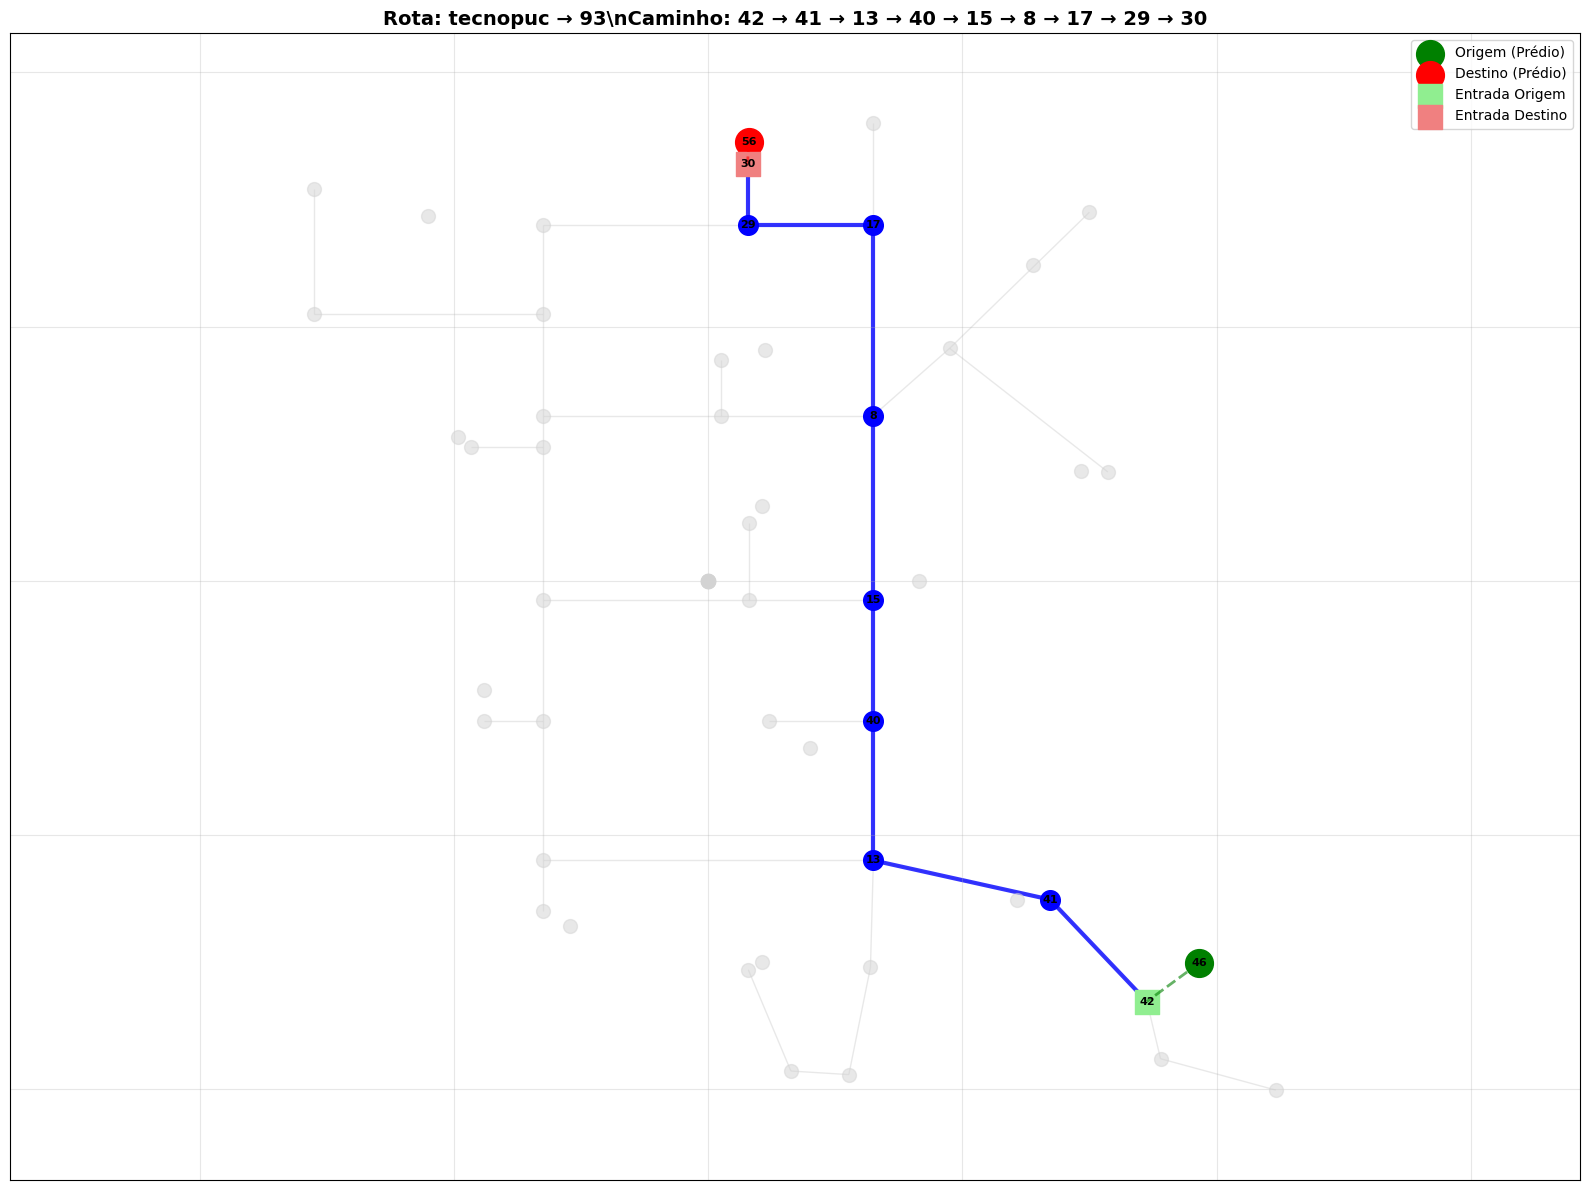

In [253]:
from_id, to_id = 1, 12
print(f"🚀 Testando rota: {BUILDINGS[from_id]['name']} → {BUILDINGS[to_id]['name']}")
path = get_route(from_id, to_id)

if path:
    print(f"✅ Caminho encontrado com {len(path)} nós")
    print(f"📍 Sequência: {' → '.join(map(str, path))}")
    plot_route(from_id, to_id, path)
else:
    print("❌ Nenhum caminho encontrado")

### Teste 3: 91 B → 91 A (prédios da mesma série)

🚀 Testando rota: 91 B → 91 A
✅ Caminho encontrado com 5 nós
📍 Sequência: 25 → 26 → 14 → 24 → 23
💾 Gráfico salvo em: output\rota_10_to_14_91 B_to_91 A.png


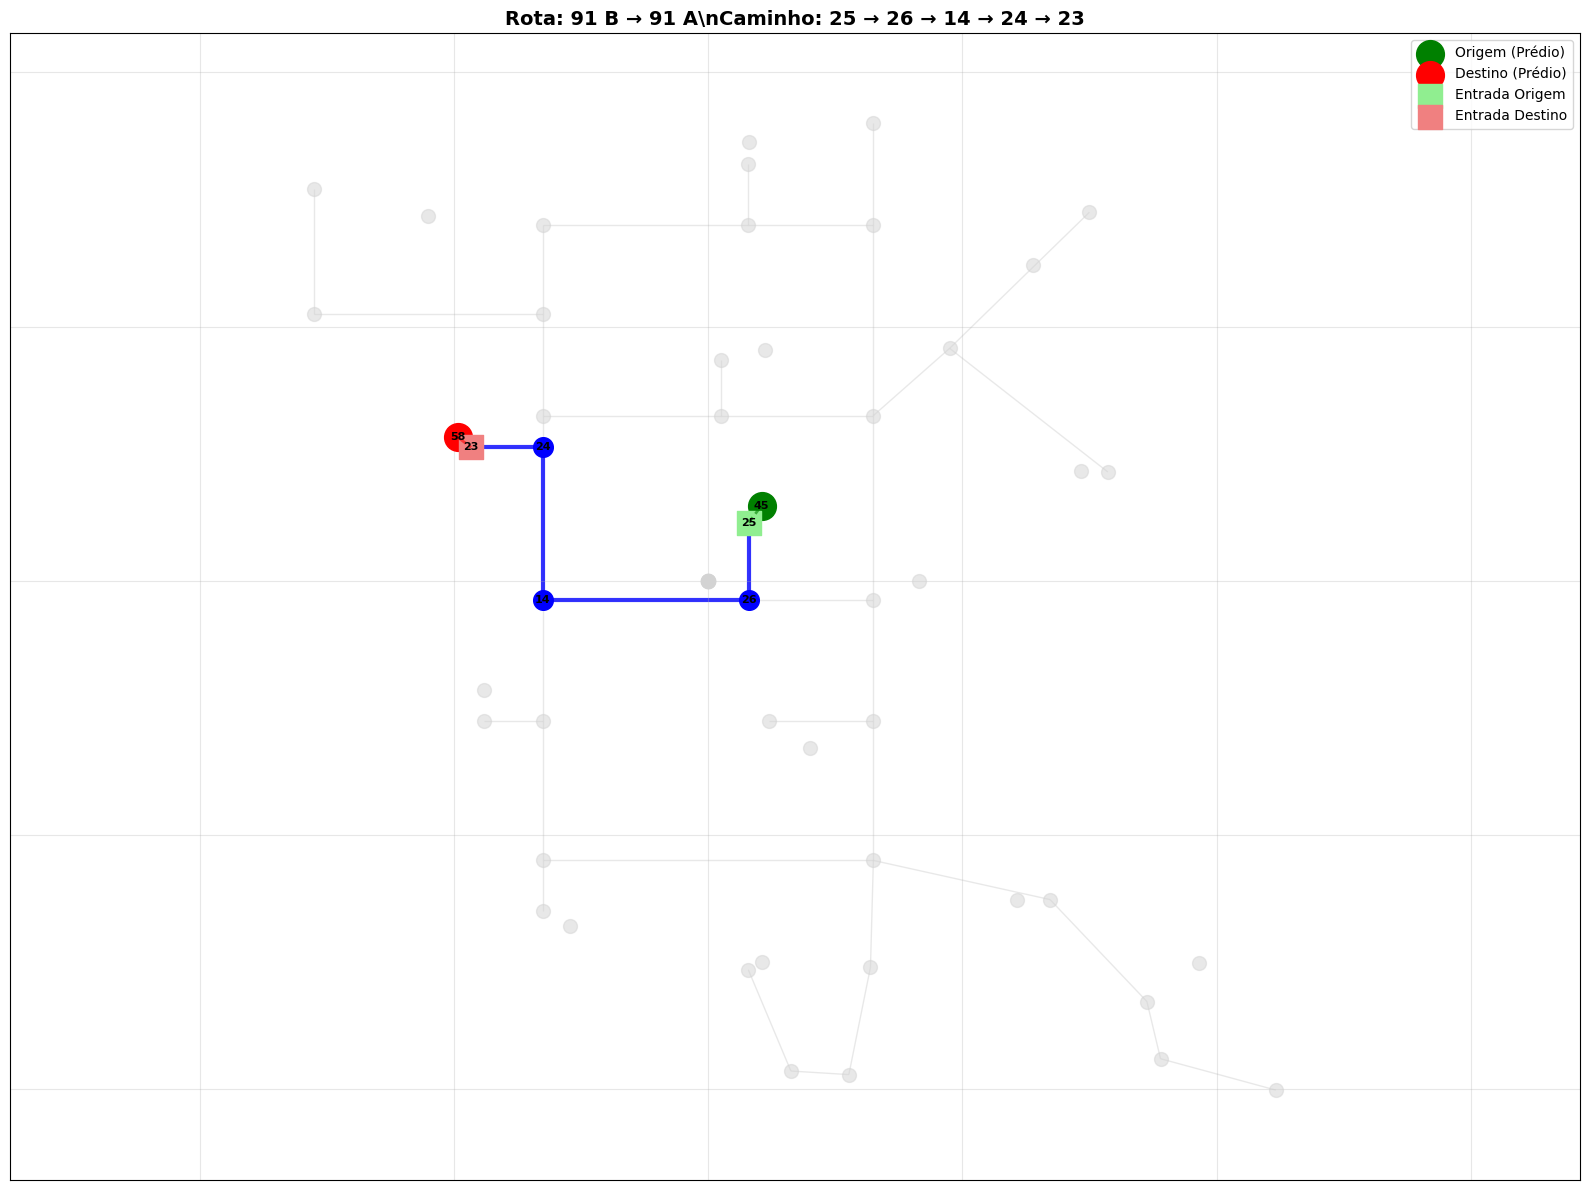

In [254]:
from_id, to_id = 10, 14
print(f"🚀 Testando rota: {BUILDINGS[from_id]['name']} → {BUILDINGS[to_id]['name']}")
path = get_route(from_id, to_id)

if path:
    print(f"✅ Caminho encontrado com {len(path)} nós")
    print(f"📍 Sequência: {' → '.join(map(str, path))}")
    plot_route(from_id, to_id, path)
else:
    print("❌ Nenhum caminho encontrado")

## 7. Teste Customizado

Agora você pode testar suas próprias rotas! Mude os valores de `origem` e `destino` na célula abaixo.

🚀 Testando rota customizada: tecnopuc → 92 A
✅ Caminho encontrado com 11 nós
📍 Sequência: 42 → 41 → 13 → 40 → 15 → 8 → 27 → 9 → 20 → 21 → 22
💾 Gráfico salvo em: output\rota_1_to_13_tecnopuc_to_92 A.png


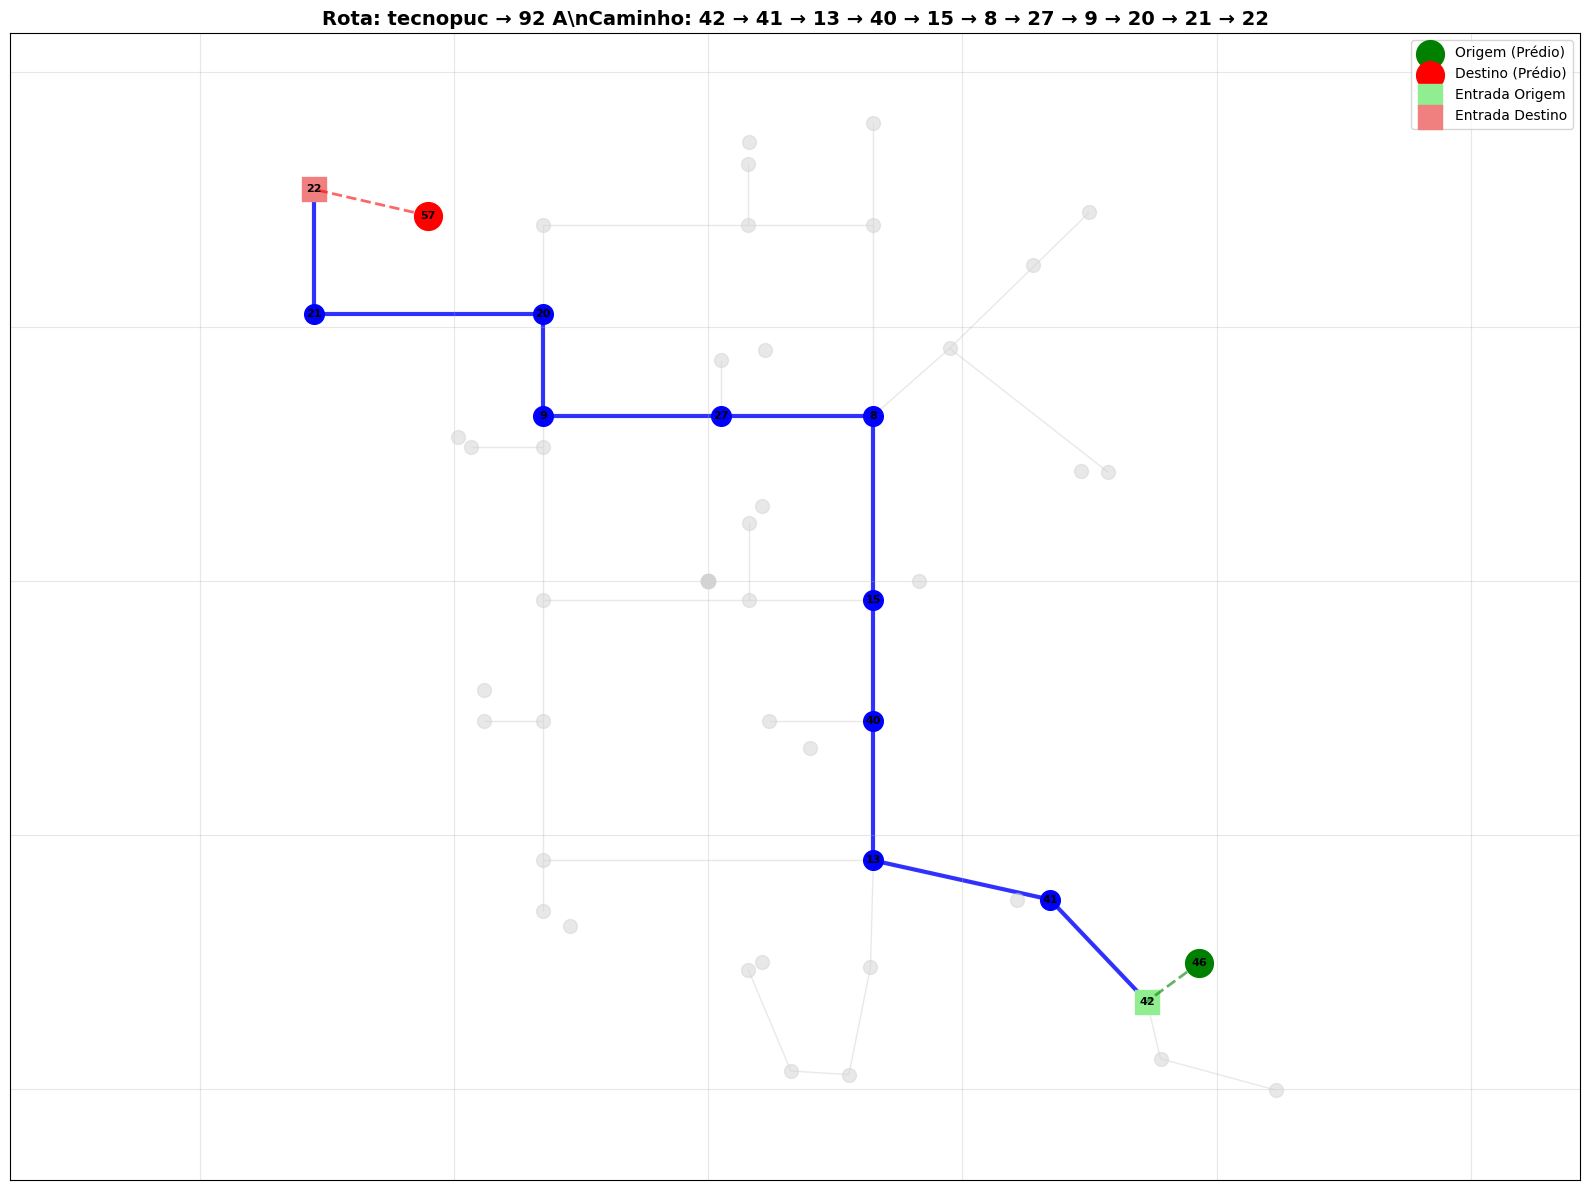

In [256]:
# 🎯 Configure sua rota aqui
origem = 1   # ID do prédio de origem (ex: 1 = Tecnopuc)
destino = 13  # ID do prédio de destino (ex: 12 = 93)

print(f"🚀 Testando rota customizada: {BUILDINGS[origem]['name']} → {BUILDINGS[destino]['name']}")
path = get_route(origem, destino)

if path:
    print(f"✅ Caminho encontrado com {len(path)} nós")
    print(f"📍 Sequência: {' → '.join(map(str, path))}")
    plot_route(origem, destino, path)
else:
    print("❌ Nenhum caminho encontrado")